# Install Modules, Libraries, Packages

In [24]:
# Data analysis tools
import pandas as pd
import numpy as np

# For timing models
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train and Testing Split
from sklearn.model_selection import train_test_split

# Classification Models
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree

# Classification Metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Regression Models
from sklearn.linear_model import LinearRegression

# Regression Metrics
from sklearn.metrics import r2_score, mean_squared_error

# Dimension Reduction
from sklearn.decomposition import PCA, KernelPCA as KPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Standardization
from sklearn.preprocessing import StandardScaler

# Functions

In [25]:
def print_info(df):
    """Prints number of rows, columns, and missing values in a dataset"""
    print(f"The dataset has:\n{df.shape[0]} rows\n{df.shape[1]} columns")
    print(f"The dataset has a total of {df.isna().sum().sum()} missing values")
    print(f"The missing values per column are:\n{df.isna().sum()}")

def clean_dataset(df):
    """Removes any missing values in a dataset"""
    if df.isna().any().any():
        #remove missing values
        df = df.dropna()

        #recalculate column and row number
        print(f"Number of rows in dataset after removing missing values: {df.shape[0]}")
        print(f"Number of columns in dataset after removing missing values: {df.shape[1]}")
    
    else:
        print("The dataset has no missing values.")
    
    return df

def standardize_data(X_train, X_test):
    """Standerdizes feature X training data and testing"""
    
    # Intialize StandardScaler
    std = StandardScaler()

    # Fit and transform the scaler to X_train and X, test
    X_train_std = std.fit_transform(X_train)
    X_test_std = std.transform(X_test)

    return X_train_std, X_test_std

# I want to create a function that will perform PCA, LDA, or KPCA if the user defines it
def dim_reduce(technique, X_train_std, X_test_std, y=None, **kwargs):
    """User defines preprocessing technique to perform on dataset"""
    
    # Check to see if the technique
    technique = technique.strip().lower()

    # establish dictionary of dimension reduction techniques
    dim_red = {"pca": PCA, 
               "lda": LDA, 
               "kpca": KPCA
               }
    
    # Check is technique
    if technique not in dim_red:
        raise ValueError(f"Invalid technique name.Please choose from {list(dim_red.keys())}")
    else:
        pass
    
    # Record start time
    start_time = time.time()
    
    # Intialize Technique
    t = dim_red[technique](**kwargs)

    # Call Technique on standerdized X and y (if appropriate)
    if technique == "lda":
        X_train_std_t = t.fit_transform(X_train_std,y)
        X_test_std_t = t.transform(X_test_std)
    
    else:
        X_train_std_t = t.fit_transform(X_train_std)
        X_test_std_t = t.transform(X_test_std)

    # Record Stop time
    stop_time = time.time() - start_time

    # Print Time
    print(f"Dimension Reduction Technique time: {stop_time:.4f} seconds")

    return t, X_train_std_t, X_test_std_t

def print_reg_metrics(y_test,y_pred):
    """Prints Metrics of a Regression Model.
       Returns error and R2 score."""
    # Store metrics in
    mse   = mean_squared_error(y_test, y_pred)
    reg_score = r2_score(y_test, y_pred)

    reg_metrics = {"mse": mse , 
               "R2 score": reg_score}

    # Print the misclassified examples and error
    print("Mean Squared Error: %.3f" % (mse))
    
    # Print regression r2_score
    print("R² score:", reg_score)

    # Return metrics
    return reg_metrics

def print_class_metrics(y_test,y_pred):
    """Prints Metrics of a classification Model.
       Returns confusion matrix, accuracy, precision, recall, and f1_score"""
    # Store metrics
    c_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    class_metrics = {"confusion_matrix": c_matrix, 
                     "accuracy": accuracy,
                     "precision": precision, 
                     "recall": recall, 
                     "f1": f1}
    # Print the misclassified examples and error
    print(f"Misclassifed examples: {(y_test != y_pred).sum()} out of {y_test.shape[0]}")
    print("Error: %.3f" % (((y_test != y_pred).sum())/(y_test.shape[0])))
    
    # Print classifier confusion matrix, accuracy, precision, and recall
    print(f"Confusion_Matrix:\n{c_matrix}")
    print("Accuracy: %.3f" % accuracy)
    print("Precision %.3f" % precision)
    print("Recall: %.3f" % recall)
    print("F1_score: %.3f" % f1)

    return class_metrics

def get_model(name):
    classifiers = {"perceptron": Perceptron,
                   "decisiontree":DecisionTreeClassifier,
                   "logisticregression":LogisticRegression,
                   "knn":KNeighborsClassifier,
                   "linearsvm": SVC,
                   "nonlinearsvm": SVC,
                   "linearregression":LinearRegression
                   }

    name = name.lower().strip().replace(" ", "") #to allow for accidental uppercase letter like Perceptron

    if name not in classifiers:
        raise ValueError(f"Invalid classifier name.Please choose from {list(classifiers.keys())}")

    return classifiers[name]
    
def classification_model(model_name,X_train_std, X_test_std, y_train, y_test, **kwargs):
    """Initalizes, Fits, and Predicts using a Classification Model"""

    #Choose classifier
    clf_class = get_model(model_name)

    # intitialize the model
    model = clf_class(**kwargs)

    # Get start time of training model
    train_start = time.time()

    # Fit the model 
    model.fit(X_train_std, y_train)

    # Stop the timer
    train_time = time.time() - train_start

    # Print training time
    print(f"Training time: {train_time:.4f} seconds")

    # Get start time of testing model
    test_start = time.time()

    # Predict the overall class, ie predicted hand number
    y_pred = model.predict(X_test_std)

    # Stop the timer
    test_time = time.time() - test_start

    # Print testing time
    print(f"Testing time: {test_time:.4f} seconds")

    # Print Metrics
    print_class_metrics(y_test, y_pred)
    
    # Return model
    return model

def regression_model(model_name,X_train_std, X_test_std, y_train, y_test, **kwargs):
    """Initalizes, Fits, and Predicts using a Regression Model"""
    #Choose classifier
    reg_model = get_model(model_name)

    # intitialize the model
    model = reg_model(**kwargs)

    # Get start time of training model
    train_start = time.time()

    # Fit the model 
    model.fit(X_train_std, y_train)

    # Stop the timer
    train_time = time.time() - train_start

    # Print training time
    print(f"Training time: {train_time:.4f} seconds")

    # Get start time of testing model
    test_start = time.time()

    # Predict the overall class, ie predicted hand number
    y_pred = model.predict(X_test_std)

    # Stop the timer
    test_time = time.time() - test_start

    # Print testing time
    print(f"Testing time: {test_time:.4f} seconds")

    # Print Metrics
    print_reg_metrics(y_test, y_pred)

    # Return model
    return model

# Load Datasets

In [26]:
# Load Census Data
US_census_data = pd.read_csv("../DATA/PROCESSED_CENSUS_DATA/US_census_data_2024.csv", index_col=0)

# Print Info
print_info(US_census_data)

# Clean Data
clean_dataset(US_census_data)

# View
US_census_data.head(20)

The dataset has:
51 rows
52 columns
The dataset has a total of 0 missing values
The missing values per column are:
state                                                                       0
Less than $10,000                                                           0
$10,000 to $14,999                                                          0
$15,000 to $24,999                                                          0
$25,000 to $34,999                                                          0
$35,000 to $49,999                                                          0
$50,000 to $74,999                                                          0
$75,000 to $99,999                                                          0
$100,000 to $149,999                                                        0
$150,000 to $199,999                                                        0
$200,000 or more                                                            0
Total                      

,state,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999","$150,000 to $199,999",...,35 to 44 years,45 to 54 years,55 to 59 years,60 to 64 years,65 to 74 years,75 to 84 years,85 years and over,Female,Male,Total population
0,Alabama,0.064,0.047,0.078,0.079,0.112,0.168,0.133,0.160,0.075,...,0.128,0.121,0.060,0.066,0.109,0.058,0.018,0.517,0.483,5157699.0
1,Alaska,0.037,0.020,0.052,0.049,0.088,0.146,0.128,0.206,0.127,...,0.146,0.112,0.049,0.065,0.095,0.041,0.011,0.473,0.527,740133.0
2,Arizona,0.049,0.025,0.056,0.061,0.104,0.164,0.139,0.183,0.098,...,0.129,0.115,0.054,0.062,0.109,0.069,0.018,0.501,0.499,7582384.0
3,Arkansas,0.060,0.046,0.082,0.090,0.128,0.176,0.128,0.158,0.066,...,0.132,0.119,0.056,0.065,0.106,0.059,0.018,0.509,0.491,3088354.0
4,California,0.046,0.030,0.050,0.049,0.079,0.131,0.114,0.179,0.112,...,0.142,0.123,0.059,0.060,0.095,0.052,0.018,0.501,0.499,39431263.0
5,Colorado,0.043,0.023,0.046,0.049,0.078,0.147,0.128,0.190,0.118,...,0.150,0.121,0.052,0.060,0.099,0.050,0.016,0.494,0.506,5957494.0
6,Connecticut,0.048,0.030,0.050,0.050,0.085,0.138,0.117,0.173,0.116,...,0.130,0.120,0.067,0.070,0.111,0.060,0.023,0.509,0.491,3675069.0
7,Delaware,0.049,0.023,0.046,0.050,0.101,0.156,0.144,0.193,0.108,...,0.126,0.111,0.062,0.075,0.129,0.066,0.021,0.518,0.482,1051917.0
8,District of Columbia,0.078,0.035,0.057,0.039,0.053,0.105,0.098,0.168,0.101,...,0.172,0.106,0.047,0.045,0.072,0.043,0.013,0.527,0.473,702250.0
9,Florida,0.052,0.031,0.061,0.067,0.106,0.167,0.132,0.177,0.089,...,0.131,0.121,0.062,0.068,0.118,0.076,0.024,0.508,0.492,23372215.0


In [27]:
# Load Crime Data
US_crime_data = pd.read_csv("../DATA/PROCESSED_CRIME_DATA/US_crime_data_2024.csv")

# Print Info
print_info(US_crime_data)

# Clean Data
clean_dataset(US_crime_data)

# View
US_crime_data.head(20)

The dataset has:
51 rows
35 columns
The dataset has a total of 0 missing values
The missing values per column are:
State                                             0
Total all classes                                 0
Violent crime                                     0
Property crime                                    0
Murder and nonnegligent manslaughter              0
Rape                                              0
Robbery                                           0
Aggravated assault                                0
Burglary                                          0
Larceny-theft                                     0
Motor vehicle theft                               0
Arson                                             0
Other assaults                                    0
Forgery and counterfeiting                        0
Fraud                                             0
Embezzlement                                      0
Stolen property; buying, receiving, possessing    0
V

,State,Total all classes,Violent crime,Property crime,Murder and nonnegligent manslaughter,Rape,Robbery,Aggravated assault,Burglary,Larceny-theft,...,Liquor laws,Drunkenness,Disorderly conduct,Vagrancy,All other offenses (except traffic),Suspicion,Curfew and loitering law violations,Abbrv,latitude,longitude
0,ALABAMA,135054,4101,11730,237,194,451,3219,1497,9578,...,6272,0,2371,0,66965,0,0,AL,32.318231,-86.902298
1,ALASKA,20014,1893,2011,29,92,226,1546,450,1264,...,84,3,666,181,5900,0,0,AK,63.588753,-154.493062
2,ARIZONA,208650,11574,24620,341,299,1537,9397,2665,20210,...,4369,73,11985,1931,67021,1,517,AZ,34.048928,-111.093731
3,ARKANSAS,106112,5547,9848,151,308,403,4685,1523,7789,...,1267,0,3283,278,47536,0,269,AR,35.201050,-91.831833
4,CALIFORNIA,590730,44098,57008,645,1379,9171,32903,8204,41542,...,1805,0,37746,4233,169212,0,99,CA,36.778261,-119.417932
5,COLORADO,175929,9171,23578,229,373,1127,7442,3012,17070,...,2647,0,4724,273,76983,0,69,CO,39.550051,-105.782067
6,CONNECTICUT,75690,2313,9213,64,133,568,1548,858,7373,...,42,0,10443,3,24370,0,0,CT,41.603221,-73.087749
7,DELAWARE,26664,1972,4309,32,55,290,1595,511,3543,...,429,0,927,55,6711,0,18,DE,38.910832,-75.527670
8,DISTRICT OF COLUMBIA,40032,1469,1626,91,46,746,586,154,1378,...,284,0,412,1,24623,0,0,DC,38.905985,-77.033418
9,FLORIDA,315030,14634,33148,318,671,2076,11569,4185,26216,...,3556,0,1971,1599,145118,0,190,FL,27.664827,-81.515754


# Combine Datasets

In [28]:
# Sub Data
total_crime = US_crime_data[["State","Total all classes","Violent crime"]]

# Change State to state
total_crime = total_crime.rename(columns={"State":"state"})

# Lower All State Names in both dataset
US_census_data['state'] = US_census_data["state"].str.lower()
total_crime["state"] = total_crime["state"].str.lower()

# Create a copy
census_df = US_census_data.copy()

# Combine
crime_census_df = pd.merge(census_df, total_crime, on="state", how="outer")

# Rename a column 
crime_census_df.rename(columns={'Total': 'Total Households'}, inplace=True)

# Calculate Crime Rate and Violent Crime Rate
crime_census_df['Crime Rate'] = crime_census_df['Total all classes'] / crime_census_df['Total population'] * 100000
crime_census_df['Violent Crime Rate'] = crime_census_df['Violent crime'] / crime_census_df['Total population'] * 100000

# Print Info
print_info(crime_census_df)

# View
crime_census_df

The dataset has:
51 rows
56 columns
The dataset has a total of 0 missing values
The missing values per column are:
state                                                                       0
Less than $10,000                                                           0
$10,000 to $14,999                                                          0
$15,000 to $24,999                                                          0
$25,000 to $34,999                                                          0
$35,000 to $49,999                                                          0
$50,000 to $74,999                                                          0
$75,000 to $99,999                                                          0
$100,000 to $149,999                                                        0
$150,000 to $199,999                                                        0
$200,000 or more                                                            0
Total Households           

,state,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999","$150,000 to $199,999",...,65 to 74 years,75 to 84 years,85 years and over,Female,Male,Total population,Total all classes,Violent crime,Crime Rate,Violent Crime Rate
0,alabama,0.064,0.047,0.078,0.079,0.112,0.168,0.133,0.160,0.075,...,0.109,0.058,0.018,0.517,0.483,5157699.0,135054,4101,2618.493247,79.512201
1,alaska,0.037,0.020,0.052,0.049,0.088,0.146,0.128,0.206,0.127,...,0.095,0.041,0.011,0.473,0.527,740133.0,20014,1893,2704.108586,255.764842
2,arizona,0.049,0.025,0.056,0.061,0.104,0.164,0.139,0.183,0.098,...,0.109,0.069,0.018,0.501,0.499,7582384.0,208650,11574,2751.773057,152.643285
3,arkansas,0.060,0.046,0.082,0.090,0.128,0.176,0.128,0.158,0.066,...,0.106,0.059,0.018,0.509,0.491,3088354.0,106112,5547,3435.875551,179.610239
4,california,0.046,0.030,0.050,0.049,0.079,0.131,0.114,0.179,0.112,...,0.095,0.052,0.018,0.501,0.499,39431263.0,590730,44098,1498.125992,111.835119
5,colorado,0.043,0.023,0.046,0.049,0.078,0.147,0.128,0.190,0.118,...,0.099,0.050,0.016,0.494,0.506,5957494.0,175929,9171,2953.070536,153.940566
6,connecticut,0.048,0.030,0.050,0.050,0.085,0.138,0.117,0.173,0.116,...,0.111,0.060,0.023,0.509,0.491,3675069.0,75690,2313,2059.553168,62.937594
7,delaware,0.049,0.023,0.046,0.050,0.101,0.156,0.144,0.193,0.108,...,0.129,0.066,0.021,0.518,0.482,1051917.0,26664,1972,2534.800749,187.467262
8,district of columbia,0.078,0.035,0.057,0.039,0.053,0.105,0.098,0.168,0.101,...,0.072,0.043,0.013,0.527,0.473,702250.0,40032,1469,5700.533998,209.184763
9,florida,0.052,0.031,0.061,0.067,0.106,0.167,0.132,0.177,0.089,...,0.118,0.076,0.024,0.508,0.492,23372215.0,315030,14634,1347.882518,62.612808


# Regression Models

## Linear Regression

In [29]:
#Create a copy 
df = crime_census_df.copy()

# Convert to totals, linear regression performs poorly with a crime rate and percentages

# Identify columns related to income
income_cols = ['Less than $10,000', '$10,000 to $14,999','$15,000 to $24,999', '$25,000 to $34,999', '$35,000 to $49,999',
               '$50,000 to $74,999', '$75,000 to $99,999', '$100,000 to $149,999',
               '$150,000 to $199,999', '$200,000 or more']

# Identify columns related to education
education_cols = ["population_18_to_24_years_bachelor's_degree_or_higher",
       "population_18_to_24_years_high_school_graduate_(includes_equivalency)",
       "population_18_to_24_years_less_than_high_school_graduate",
       "population_18_to_24_years_some_college_or_associate's_degree",
       "population_25_to_34_years_bachelor's_degree_or_higher",
       "population_25_to_34_years_high_school_graduate_or_higher",
       "population_25_years_and_over_9th_to_12th_grade,_no_diploma",
       "population_25_years_and_over_associate's_degree",
       "population_25_years_and_over_bachelor's_degree",
       "population_25_years_and_over_bachelor's_degree_or_higher",
       "population_25_years_and_over_graduate_or_professional_degree",
       'population_25_years_and_over_high_school_graduate_(includes_equivalency)',
       'population_25_years_and_over_high_school_graduate_or_higher',
       'population_25_years_and_over_less_than_9th_grade',
       'population_25_years_and_over_some_college,_no_degree',
       "population_35_to_44_years_bachelor's_degree_or_higher",
       "population_35_to_44_years_high_school_graduate_or_higher",
       "population_45_to_64_years_bachelor's_degree_or_higher",
       'population_45_to_64_years_high_school_graduate_or_higher',
       "population_65_years_and_over_bachelor's_degree_or_higher",
       'population_65_years_and_over_high_school_graduate_or_higher']

# Identify columns related to employment
labor_cols = ['In labor force', 'Not in labor force']

# Identify columns related to age and sex
age_sex_cols = ['Under 5 years', '5 to 9 years', '10 to 14 years', '15 to 19 years',
       '20 to 24 years', '25 to 34 years', '35 to 44 years', '45 to 54 years',
       '55 to 59 years', '60 to 64 years', '65 to 74 years', '75 to 84 years',
       '85 years and over', 'Female', 'Male']

# Convert percentages to totals using total housholds for income columns
df[income_cols] = df.apply(lambda row: row[income_cols] * row['Total Households'], axis=1)
df[income_cols] = df[income_cols].round(0).astype(int)

# Convert percentages to totals using total population for income education columns
df[education_cols] = df.apply(lambda row: row[education_cols] * row['Total population'], axis=1)
df[education_cols] = df[education_cols].round(0).astype(int)

# Convert percentages to totals using total housholds for employment columns
df[labor_cols] = df.apply(lambda row: row[labor_cols] * row['Population 16 years and over'], axis=1)
df[labor_cols] = df[labor_cols].round(0).astype(int)

# Convert percentages to totals using total population for age and sex columns
df[age_sex_cols] = df.apply(lambda row: row[age_sex_cols] * row['Total population'], axis=1)
df[age_sex_cols] = df[age_sex_cols].round(0).astype(int)

# Store a copy just in case you need it later 
total_df = df.copy()

# Establish X and y
X = df.drop(columns=["state","Total all classes","Violent crime","Crime Rate","Violent Crime Rate"])

y = df["Violent crime"]

# Split data into testing and training
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.8,random_state=1)

# Standardize X_train X_test
X_train_std, X_test_std = standardize_data(X_train, X_test)

# Choose the model
reg_model= "linear regression"

# Without Dimension Reduction but with Feature Scaling
lr = regression_model(reg_model,X_train_std, X_test_std, y_train, y_test)

Training time: 0.0014 seconds
Testing time: 0.0002 seconds
Mean Squared Error: 80719150.226
R² score: 0.42949286126484754


                                              Feature    Coefficient
27  population_35_to_44_years_high_school_graduate...  176945.575966
33                                 Not in labor force -112207.585147
22  population_25_years_and_over_high_school_gradu...   97706.563235
30  population_65_years_and_over_bachelor's_degree...   91072.585961
6                                  $75,000 to $99,999   89910.350633
38                                     15 to 19 years  -87654.931301
34                       Population 16 years and over  -87205.941035
49                                               Male  -83706.589334
32                                     In labor force  -73046.039698
19     population_25_years_and_over_bachelor's_degree  -72927.258007


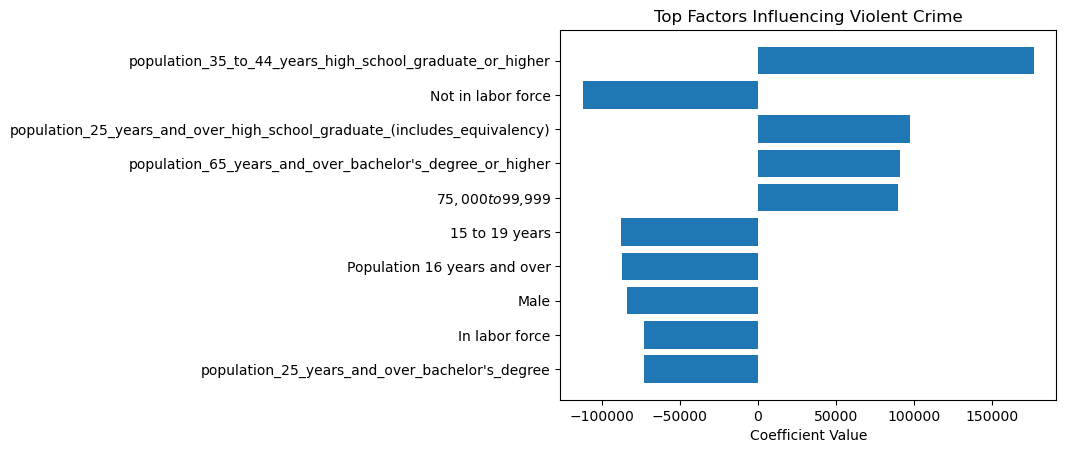

In [30]:
# View Coeffiecients by Feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coefficients.head(10))

# Plot Top Factors Influencing Violent Crime
top_features = coefficients.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Factors Influencing Violent Crime")
plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()
plt.savefig("../FIGURES/Figure_10")
plt.show()

### W/ PCA

Dimension Reduction Technique time: 0.0055 seconds


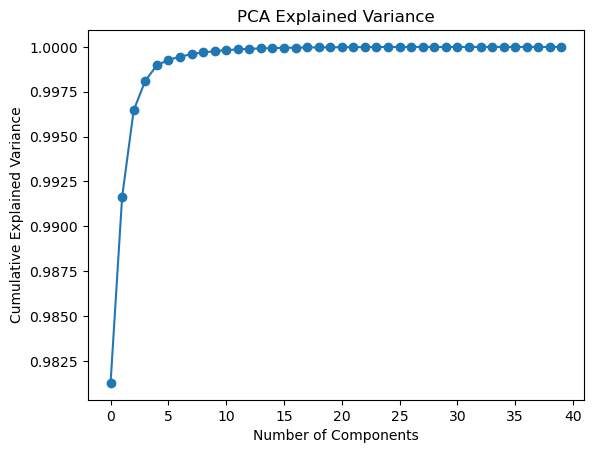

In [31]:
# Return PCA model and apply on x train and x test data
pca, X_train_std_pca, X_test_std_pca = dim_reduce("pca", X_train_std, X_test_std)

# Visualize the explained variance of each component
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.savefig("../FIGURES/Figure_11")
plt.show()

In [32]:
# According to the graph above, we can keep 10 components
pca, X_train_std_pca, X_test_std_pca = dim_reduce("pca", X_train_std, X_test_std, n_components = 10)

pca_df = pd.DataFrame(
    X_train_std_pca,
    columns=[f"PC{i+1}" for i in range(10)]
)

pca_df.head()

Dimension Reduction Technique time: 0.0067 seconds


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-4.709334,0.375165,0.045993,0.028255,-0.078266,-0.022136,0.056222,-0.000563,0.011042,0.011814
1,1.185523,0.445476,0.294136,-0.442391,-0.361725,-0.059797,-0.159848,-0.248713,0.136242,-0.008289
2,-5.147541,0.271014,-0.106042,0.083397,-0.097077,-0.044500,0.025870,0.071622,0.041534,-0.018339
3,-4.966047,0.351587,-0.049944,0.100505,0.017295,0.022429,0.035102,0.071351,0.022875,0.014163
4,0.623854,0.840265,0.645182,-0.514610,0.334383,0.254843,0.031244,0.058184,0.028632,-0.039236


In [33]:
# ReRun Linear Regression with PCA
lr = regression_model(reg_model,X_train_std_pca, X_test_std_pca, y_train, y_test)

Training time: 0.0013 seconds
Testing time: 0.0002 seconds
Mean Squared Error: 123411916.147
R² score: 0.12774875640166472


                                                         PC1       PC2  \
Less than $10,000                                   0.139800 -0.172782   
$10,000 to $14,999                                  0.139012 -0.183731   
$15,000 to $24,999                                  0.138388 -0.262985   
$25,000 to $34,999                                  0.137163 -0.324808   
$35,000 to $49,999                                  0.138000 -0.294421   
$50,000 to $74,999                                  0.139053 -0.238254   
$75,000 to $99,999                                  0.140310 -0.152476   
$100,000 to $149,999                                0.141122 -0.021475   
$150,000 to $199,999                                0.140284  0.141913   
$200,000 or more                                    0.135064  0.391726   
Total Households                                    0.141213 -0.050478   
population_18_to_24_years_bachelor's_degree_or_...  0.139791  0.098991   
population_18_to_24_years_high_school_

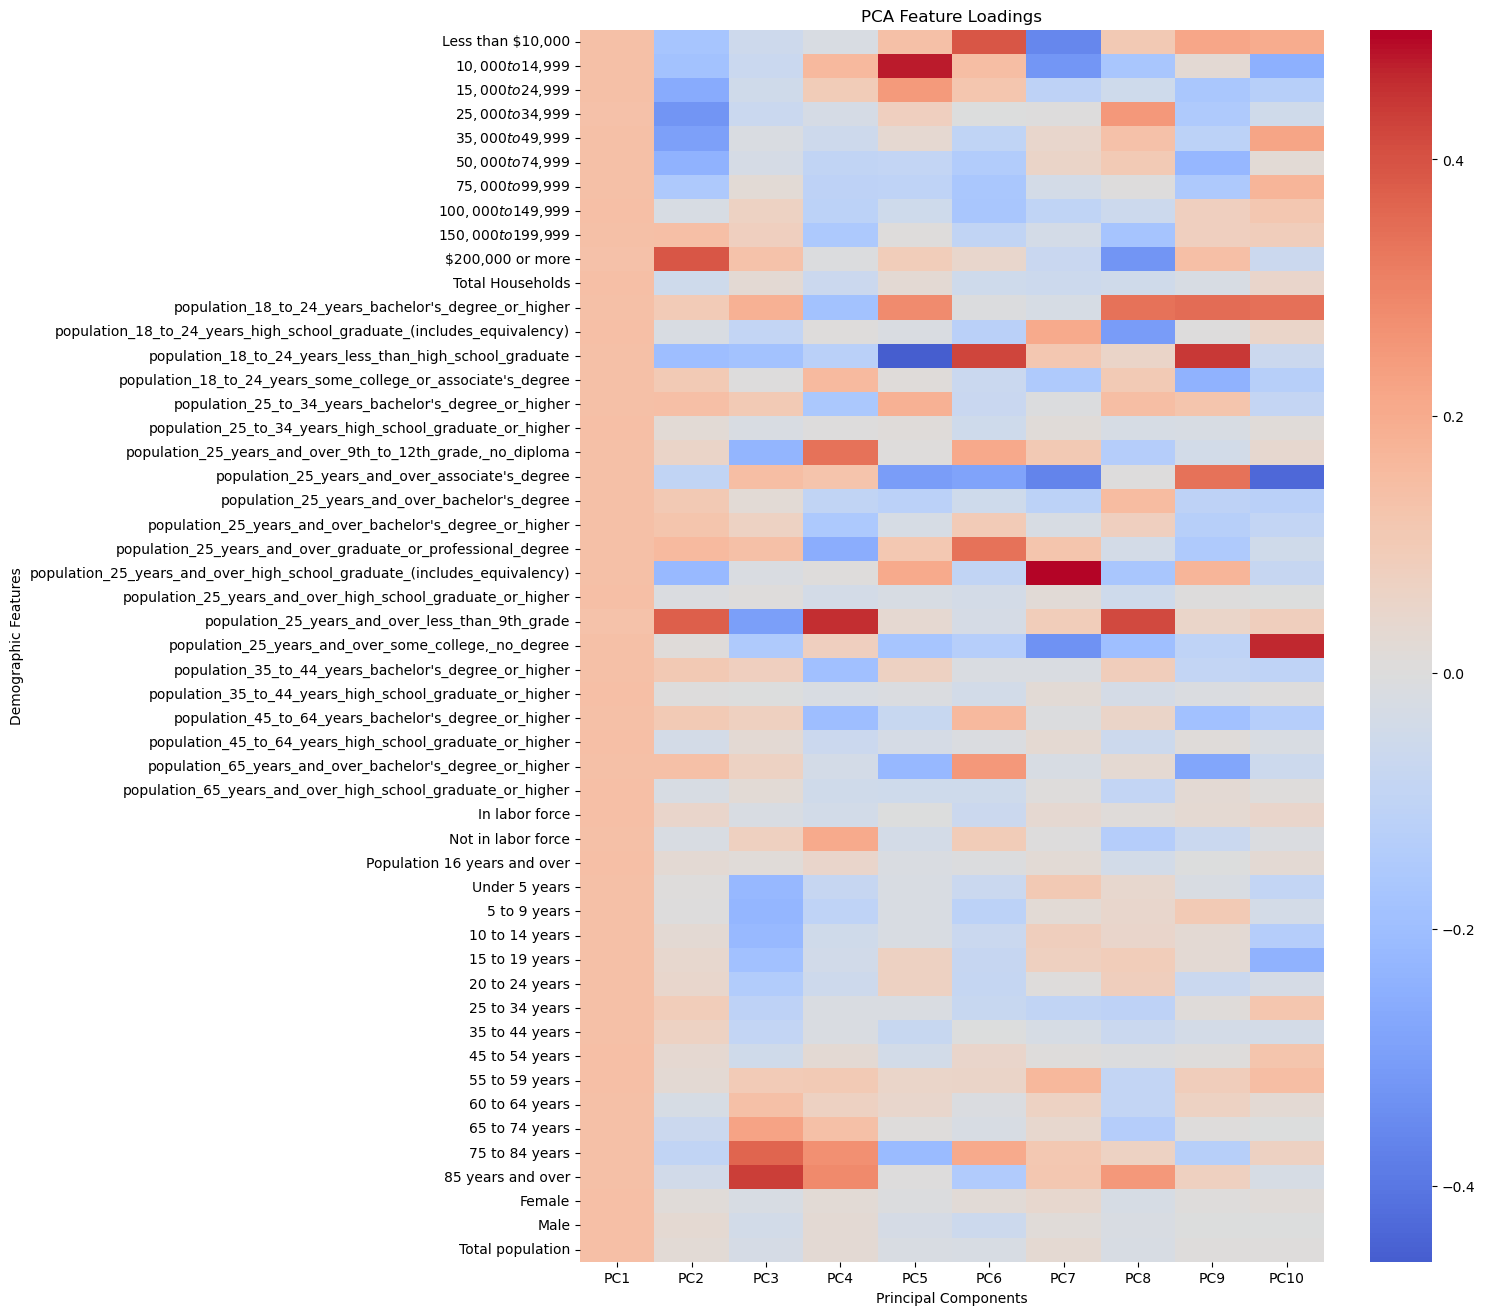

In [34]:
# VIEW PC by Feature
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(10)],
    index=X.columns
)

print(loadings)

# Plot into a HeatMap
plt.figure(figsize=(12,16))

sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Feature Loadings")
plt.xlabel("Principal Components")
plt.ylabel("Demographic Features")

plt.savefig("../FIGURES/Figure_12.jpg")
plt.show()

In [35]:
coefficients = pd.DataFrame({
    "Component": pca_df.columns,
    "Influence": lr.coef_
})

coefficients

,Component,Influence
0,PC1,1111.337457
1,PC2,1921.177414
2,PC3,-1996.507731
3,PC4,-309.930526
4,PC5,1412.768098
5,PC6,-1319.355773
6,PC7,5031.965153
7,PC8,-10342.273263
8,PC9,-6334.921551
9,PC10,1827.586017


Not much improvement with PCA. 

# Classification Models

## Logisitic Regresssion

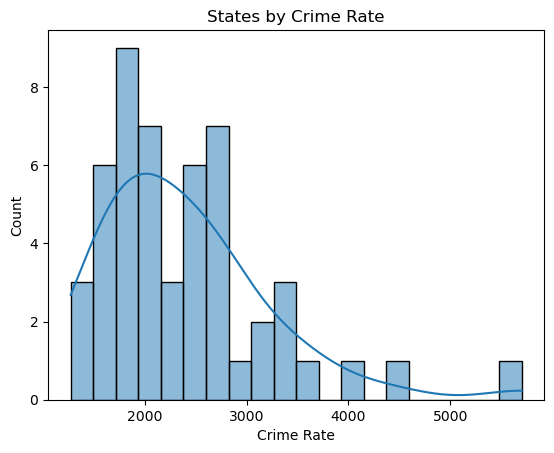

In [36]:
sns.histplot(crime_census_df["Crime Rate"], bins=20, kde=True) # just the raw data
plt.title("States by Crime Rate")  
plt.show()

In [37]:
# Create a copy 
df = crime_census_df.copy()

# Establish X and y
X = df.drop(columns=["state","Total Households", "Total population", "Population 16 years and over",
                            "Total all classes","Violent crime",
                            "Crime Rate","Violent Crime Rate"])

# 
low_thresh = df["Crime Rate"].quantile(0.33)
high_thresh = df["Crime Rate"].quantile(0.67)

df["crime rate class"] = df["Crime Rate"].apply(
    lambda x: "low" if x <= low_thresh else ("high" if x >= high_thresh else "medium")
)
y = df["crime rate class"]

# Split data into testing and training
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.8,stratify=y,random_state=1)

# Standardize X_train X_test
X_train_std, X_test_std = standardize_data(X_train, X_test)

# Choose the model
class_model= "logistic regression"

# Without Dimension Reduction but with Feature Scaling, perform decision tree classification on dataset
log = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,random_state=1, 
                     penalty='l2',        # regularization type
                     C=0.5,               # regularization strength
                     solver='lbfgs',  # optimizer
                     max_iter=200)       # iterations

Training time: 0.0069 seconds
Testing time: 0.0002 seconds
Misclassifed examples: 8 out of 11
Error: 0.727
Confusion_Matrix:
[[0 0 3]
 [2 2 0]
 [2 1 1]]
Accuracy: 0.273
Precision 0.333
Recall: 0.273
F1_score: 0.299


In [38]:
print(log.classes_)

['high' 'low' 'medium']


                                              Feature  Coefficient
45                                  85 years and over    -0.663496
38                                     25 to 34 years     0.434142
12  population_18_to_24_years_less_than_high_schoo...    -0.391684
6                                  $75,000 to $99,999     0.385516
39                                     35 to 44 years     0.359596
0                                   Less than $10,000     0.272729
40                                     45 to 54 years     0.269169
25  population_35_to_44_years_bachelor's_degree_or...    -0.263130
24  population_25_years_and_over_some_college,_no_...     0.252647
15  population_25_to_34_years_high_school_graduate...     0.250129


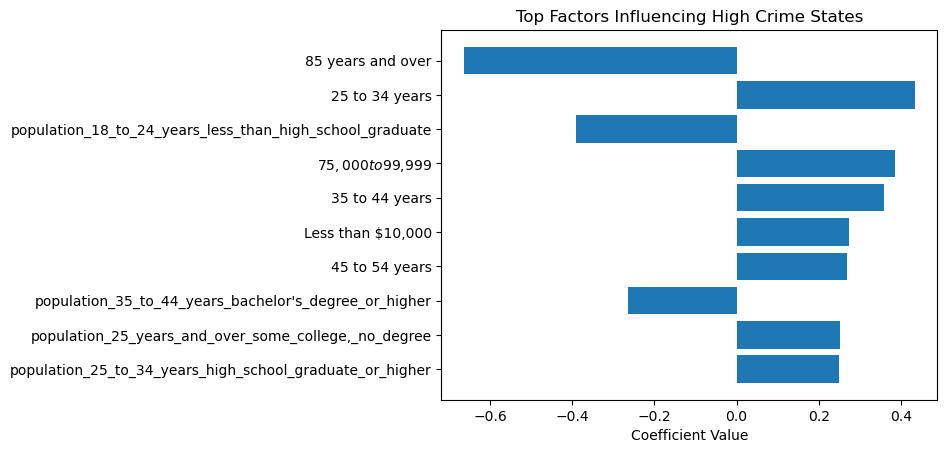

In [39]:
# View Coeffiecients by Feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coefficients.head(10))

# Plot Top Factors Influencing Violent Crime
top_features = coefficients.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Factors Influencing High Crime States")
plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()
plt.savefig("../FIGURES/Figure_13")
plt.show()

                                              Feature  Coefficient
12  population_18_to_24_years_less_than_high_schoo...     0.527661
39                                     35 to 44 years    -0.509239
40                                     45 to 54 years     0.425792
24  population_25_years_and_over_some_college,_no_...    -0.363463
29  population_65_years_and_over_bachelor's_degree...    -0.355114
6                                  $75,000 to $99,999    -0.354468
5                                  $50,000 to $74,999    -0.313989
45                                  85 years and over     0.278488
11  population_18_to_24_years_high_school_graduate...    -0.269647
26  population_35_to_44_years_high_school_graduate...    -0.266453


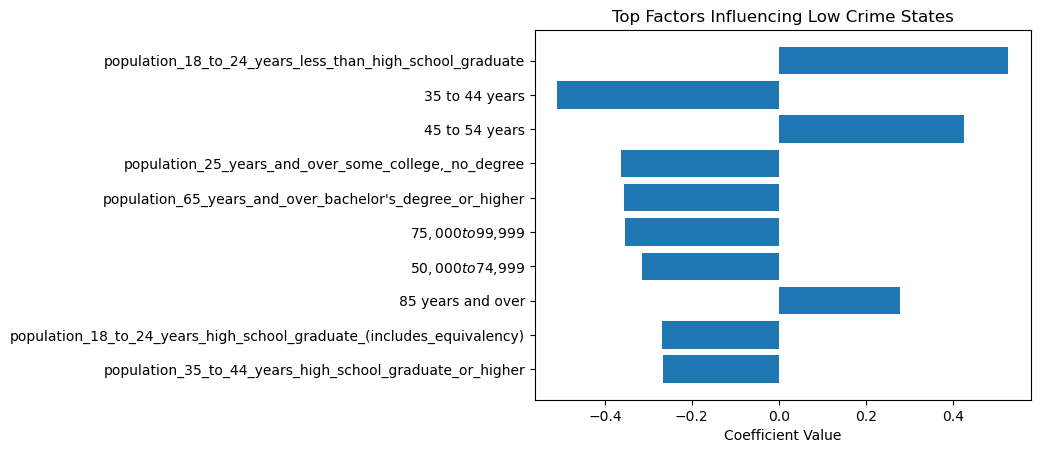

In [40]:
# View Coeffiecients by Feature
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log.coef_[1]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coefficients.head(10))

# Plot Top Factors Influencing Violent Crime
top_features = coefficients.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Factors Influencing Low Crime States")
plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()
plt.savefig("../FIGURES/Figure_14")
plt.show()

### W/ PCA

In [41]:
# Establish Dimension Reduction Technique
technique="pca"

# Call Dimension Reduction Technique
pca,X_train_std_pca, X_test_std_pca = dim_reduce(technique,X_train_std, X_test_std, y_train,n_components=10)

# Classify with Decision Tree, Feature Scaling, AND Dimension Reduction Technique
log_pca = classification_model(class_model,X_train_std_pca, X_test_std_pca, y_train, y_test,random_state=1, 
                     penalty='l2',        # regularization type
                     C=0.5,               # regularization strength
                     solver='lbfgs',  # optimizer
                     max_iter=200)

Dimension Reduction Technique time: 0.0035 seconds
Training time: 0.0087 seconds
Testing time: 0.0002 seconds
Misclassifed examples: 8 out of 11
Error: 0.727
Confusion_Matrix:
[[0 0 3]
 [1 3 0]
 [2 2 0]]
Accuracy: 0.273
Precision 0.218
Recall: 0.273
F1_score: 0.242


## NON Linear SVM

In [42]:
# Choose the model
class_model= "non linear svm"

# Without Dimension Reduction but with Feature Scaling, perform decision tree classification on dataset
nl_svm = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,kernel="rbf", gamma=0.10, C=10.0, random_state=1)

Training time: 0.0037 seconds
Testing time: 0.0008 seconds
Misclassifed examples: 5 out of 11
Error: 0.455
Confusion_Matrix:
[[1 0 2]
 [0 4 0]
 [3 0 1]]
Accuracy: 0.545
Precision 0.553
Recall: 0.545
F1_score: 0.545


### W/ KPCA

In [43]:
# Establish Dimension Reduction Technique
technique="kpca"

# Call Dimension Reduction Technique
kpca, X_train_std_kpca, X_test_std_kpca = dim_reduce(technique,X_train_std, X_test_std, y_train,n_components=10, kernel='rbf', gamma=0.25)

# Classify with nonlinear svm, Feature Scaling, AND Dimension Reduction Technique
nl_svm_pca = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,kernel="rbf", gamma=0.10, C=10.0, random_state=1)

Dimension Reduction Technique time: 0.0124 seconds
Training time: 0.0030 seconds
Testing time: 0.0008 seconds
Misclassifed examples: 5 out of 11
Error: 0.455
Confusion_Matrix:
[[1 0 2]
 [0 4 0]
 [3 0 1]]
Accuracy: 0.545
Precision 0.553
Recall: 0.545
F1_score: 0.545


## Decision Tree

In [44]:
# Choose the model
class_model= "decision tree"

# Without Dimension Reduction but with Feature Scaling, perform decision tree classification on dataset
dt = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,criterion="gini", max_depth=10, random_state=1)

Training time: 0.0027 seconds
Testing time: 0.0004 seconds
Misclassifed examples: 6 out of 11
Error: 0.545
Confusion_Matrix:
[[1 0 2]
 [0 3 1]
 [2 1 1]]
Accuracy: 0.455
Precision 0.455
Recall: 0.455
F1_score: 0.455


## KNN

In [45]:
# Choose the model
class_model= "knn"

# Without Dimension Reduction but with Feature Scaling, perform decision tree classification on dataset
knn = classification_model(class_model,X_train_std, X_test_std, y_train, y_test,n_neighbors=7,metric="euclidean")


Training time: 0.0017 seconds
Testing time: 0.0152 seconds
Misclassifed examples: 6 out of 11
Error: 0.545
Confusion_Matrix:
[[0 0 3]
 [0 4 0]
 [1 2 1]]
Accuracy: 0.455
Precision 0.333
Recall: 0.455
F1_score: 0.382


# FIGURES

In [46]:
import plotly.express as px
import pandas as pd

crime_data = US_crime_data.copy()

crime_data = crime_data.rename(columns={"State":"state"})
crime_data["state"] = crime_data["state"].str.lower()

# Merge crime_df into main_df on the 'state' column
combined_df = pd.merge(crime_data, crime_census_df[['state', 'Violent Crime Rate']],
                       on='state',
                       how='left')  # 'left' keeps all rows from main_df


fig = px.scatter_mapbox(
    combined_df,
    lat="latitude",
    lon="longitude",
    size="Violent Crime Rate",
    color="Violent Crime Rate",
    hover_name="state",
    hover_data=["state", "Violent Crime Rate"],
    color_continuous_scale="Viridis",
    size_max=40,
    zoom=3
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0,"t":0,"l":0,"b":0}
)

plt.savefig("../FIGURES/Figure_15.jpg")

fig.show()

C:\Users\laura\AppData\Local\Temp\ipykernel_17444\1585769594.py:15: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



<Figure size 640x480 with 0 Axes>